# 04 · Your own weather

Prepare daily station weather, check it, and compare Gainesville maize yield with the original stock weather.

## You will learn

- Map daily measurements into the weather template with DSSAT units.
- Read a weather check message, correct one row, and summarize the year.
- Run maize with your weather data and compare grain yield with stock weather.

In [1]:
LESSON = "04_own_weather"

In [2]:
# Connect to DSSAT and prepare a fresh copy of the lesson's data.
import os, shutil, subprocess, sys
from pathlib import Path
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "dssatlab[course]>=0.23,<0.24"], check=True, capture_output=True)
    if Path.cwd().name != LESSON:
        if not Path("dssatlab").exists():
            subprocess.run(["git", "clone", "--depth", "1", "https://github.com/AbdelrahmanAmr3/dssatlab"], check=True)
        os.chdir(Path("dssatlab") / "course" / LESSON)
import dssatlab as dl
if "google.colab" in sys.modules:
    dl.install()
dssat = dl.connect()
HERE = Path.cwd()
RUNS = HERE / "runs"
if RUNS.exists():
    shutil.rmtree(RUNS)
_ = shutil.copytree(HERE / "data", RUNS)

Load the tools for weather tables and inline plots.

In [3]:
# Load the lesson tools.
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
print("Tools ready: weather tables and plots.")

Tools ready: weather tables and plots.


Write and preview the example weather template before replacing its demonstration values with your measurements.

In [4]:
# Show the template's seven example days.
template = RUNS / "weather_template.csv"
if not template.exists():
    dl.write_weather_template(template)
pd.read_csv(template, keep_default_na=False)

,station,latitude,longitude,elevation,date,srad,tmax,tmin,rain,tav,amp,refht,wndht
0,DEMO,45,-100,200,2021-03-01,20,25,10,0,-99,-99,-99,-99
1,DEMO,45,-100,200,2021-03-02,20,25,10,0,-99,-99,-99,-99
2,DEMO,45,-100,200,2021-03-03,20,25,10,0,-99,-99,-99,-99
3,DEMO,45,-100,200,2021-03-04,20,25,10,0,-99,-99,-99,-99
4,DEMO,45,-100,200,2021-03-05,20,25,10,0,-99,-99,-99,-99
5,DEMO,45,-100,200,2021-03-06,20,25,10,0,-99,-99,-99,-99
6,DEMO,45,-100,200,2021-03-07,20,25,10,0,-99,-99,-99,-99


🌱 Crop idea  
The template has only seven days at station `DEMO` in 2021; it cannot supply this 1982 crop season.
Our CSV uses all 365 measured days from stock Gainesville weather as your station data.

Map the stock weather headings into the exact CSV names and units, retaining PAR as well as solar radiation.

In [5]:
# Show the source-to-template mapping with the first day's values.
weather = pd.read_csv(RUNS / "station_weather.csv", keep_default_na=False)
mapping = [
    ("INSI", "station", "four-character code"),
    ("LAT", "latitude", "degrees north"),
    ("LONG", "longitude", "degrees east"),
    ("ELEV", "elevation", "m"),
    ("DATE (YYDDD)", "date", "YYYY-MM-DD"),
    ("SRAD", "srad", "MJ/m² per day"),
    ("TMAX", "tmax", "°C"),
    ("TMIN", "tmin", "°C"),
    ("RAIN", "rain", "mm per day"),
    ("TAV", "tav", "°C"),
    ("AMP", "amp", "°C"),
    ("REFHT", "refht", "m"),
    ("WNDHT", "wndht", "m"),
    ("PAR (optional)", "par", "mol/m² per day"),
]
pd.DataFrame([{"Stock heading": source, "CSV column": column,
               "Unit or format": unit, "First day": weather.loc[0, column]}
              for source, column, unit in mapping])

,Stock heading,CSV column,Unit or format,First day
0,INSI,station,four-character code,UFGA
1,LAT,latitude,degrees north,29.63
2,LONG,longitude,degrees east,-82.37
3,ELEV,elevation,m,10
4,DATE (YYDDD),date,YYYY-MM-DD,1982-01-01
5,SRAD,srad,MJ/m² per day,5.9
6,TMAX,tmax,°C,24.4
7,TMIN,tmin,°C,15.6
8,RAIN,rain,mm per day,19.0
9,TAV,tav,°C,20.9


🐍 Python idea  
`.loc[0, "tmax"]` selects the first data row; a check calls this row 2 because the CSV header counts as row 1.
Keep one row per day in date order and repeat the station values, with `UFGA` matching this FileX.

Preview the first five measured days to see the weather data you will check and run.

In [6]:
# Preview daily measurements from the copied station CSV.
weather[["date", "srad", "tmax", "tmin", "rain", "par"]].head()

,date,srad,tmax,tmin,rain,par
0,1982-01-01,5.9,24.4,15.6,19.0,12.4
1,1982-01-02,7.0,22.2,15.0,0.0,14.2
2,1982-01-03,9.0,27.8,17.2,0.0,18.4
3,1982-01-04,3.1,26.1,15.0,9.4,6.4
4,1982-01-05,12.9,17.2,2.2,0.0,26.3


Make one maximum temperature lower than its minimum and read the error that prevents DSSAT from running.

In [7]:
# Deliberately break one row and display its check error.
broken_weather = weather.copy()
broken_weather.loc[0, "tmax"] = broken_weather.loc[0, "tmin"] - 1
broken_sim = dl.Simulation(filex=RUNS / "UFGA8201.MZX", treatment=1,
                           weather=broken_weather, soil=RUNS / "SOIL.SOL", executable=dssat)
try:
    broken_result = broken_sim.run()
except dl.DSSATCheckError as error:
    print("DSSATCheckError:", str(error))

DSSATCheckError: Simulation checks found 1 problems:
Weather data row 2: tmax 14.6 is below tmin 15.6 degrees C. Correct tmax or tmin so tmax >= tmin.


Restore the measured maximum temperature and check the corrected weather against treatment 1 and its simulation start date.

In [8]:
# Restore the original value and confirm that no problems remain.
broken_weather.loc[0, "tmax"] = weather.loc[0, "tmax"]
sim = dl.Simulation(filex=RUNS / "UFGA8201.MZX", treatment=1,
                    weather=broken_weather, soil=RUNS / "SOIL.SOL", executable=dssat)
problems = sim.check(verbose=False)
print("Restored first-day tmax:", broken_weather.loc[0, "tmax"], "°C; problems:", problems)

Restored first-day tmax: 24.4 °C; problems: []


Summarize the full year to check its coverage, average daily weather and total rainfall.

In [9]:
# Display the station's coverage and annual weather summary.
weather_summary = dl.summarize_weather(RUNS / "station_weather.csv")
year = weather_summary["years"][0]
pd.DataFrame([{
    "Station": weather_summary["station"],
    "First date": weather_summary["first_date"],
    "Last date": weather_summary["last_date"],
    "Days": year["days"],
    "Mean srad (MJ/m²/day)": year["srad_mean"],
    "Mean tmax (°C)": year["tmax_mean"],
    "Mean tmin (°C)": year["tmin_mean"],
    "Rain total (mm)": year["rain_total"],
    "Mean PAR (mol/m²/day)": year["par_mean"],
}]).T.rename(columns={0: "1982 weather"})

,1982 weather
Station,UFGA
First date,1982-01-01
Last date,1982-12-31
Days,365
Mean srad (MJ/m²/day),14.65
Mean tmax (°C),28.27
Mean tmin (°C),15.69
Rain total (mm),1544.5
Mean PAR (mol/m²/day),29.66


Plot daily temperatures and rainfall to inspect the weather through the year.

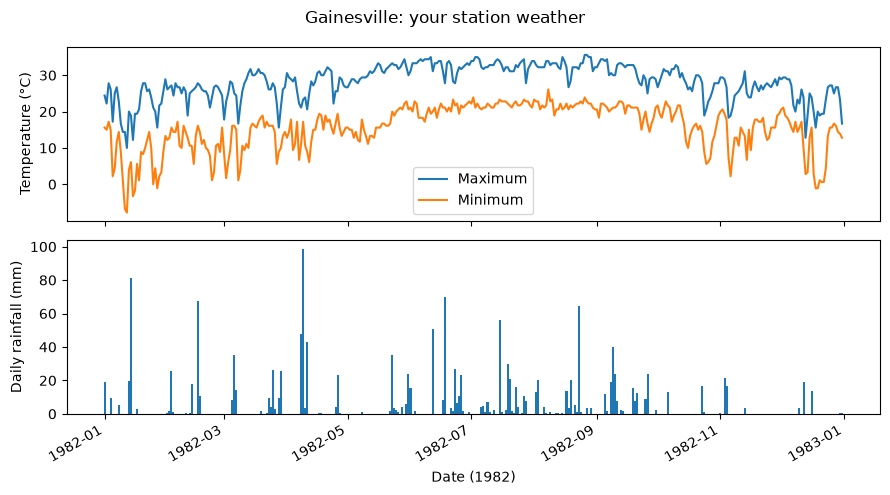

In [10]:
# Plot measured daily weather with its units.
daily = weather.copy()
daily["date"] = pd.to_datetime(daily["date"])
fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
axes[0].plot(daily["date"], daily["tmax"], label="Maximum")
axes[0].plot(daily["date"], daily["tmin"], label="Minimum")
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend()
axes[1].bar(daily["date"], daily["rain"], width=1)
axes[1].set(ylabel="Daily rainfall (mm)", xlabel="Date (1982)")
fig.suptitle("Gainesville: your station weather")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Run treatment 1 with stock weather and with the corrected CSV values, then compare grain yield (`HWAM`, kg/ha).

In [11]:
# Compare the same maize treatment using stock and template weather.
stock_sim = dl.Simulation(filex=RUNS / "UFGA8201.MZX", treatment=1,
                          weather=RUNS / "UFGA8201.WTH", soil=RUNS / "SOIL.SOL", executable=dssat)
stock_result = stock_sim.run()
station_result = sim.run()
stock_row = dl.read_summary(stock_result.run_dir)[0]
station_row = dl.read_summary(station_result.run_dir)[0]
pd.DataFrame([{
    "Treatment": 1,
    "Stock HWAM (kg/ha)": stock_row["HWAM"],
    "Your station HWAM (kg/ha)": station_row["HWAM"],
    "Station minus stock (kg/ha)": station_row["HWAM"] - stock_row["HWAM"],
}])

,Treatment,Stock HWAM (kg/ha),Your station HWAM (kg/ha),Station minus stock (kg/ha)
0,1,2293,2293,0


🌱 Crop idea  
Both runs give 2,293 kg/ha, a difference of 0; this is consistent with preserving the weather values, including PAR and station metadata.
Treatment 1 keeps its stock water and nitrogen simulation and management, including its small reported irrigation.

## Your turn

Summarize one month to compare its weather with the annual table.

Hint: edit `chosen_month = 6` (1 = January, 12 = December), then run this cell.

In [12]:
# Choose a month and rebuild its weather summary from the CSV.
chosen_month = 6
exercise_weather = pd.read_csv(RUNS / "station_weather.csv", keep_default_na=False)
months = pd.to_datetime(exercise_weather["date"]).dt.month
month_weather = exercise_weather.loc[months == chosen_month].copy()
month_summary = dl.summarize_weather(month_weather)
pd.DataFrame([{
    "First date": month_summary["first_date"],
    "Last date": month_summary["last_date"],
    "Days": month_summary["days"],
    "Mean srad (MJ/m²/day)": month_summary["variables"]["srad"]["mean"],
    "Mean tmax (°C)": month_summary["variables"]["tmax"]["mean"],
    "Mean tmin (°C)": month_summary["variables"]["tmin"]["mean"],
    "Rain total (mm)": month_summary["rain_total"],
}]).T.rename(columns={0: "Chosen month"})

,Chosen month
First date,1982-06-01
Last date,1982-06-30
Days,30
Mean srad (MJ/m²/day),21.09
Mean tmax (°C),32.58
Mean tmin (°C),20.66
Rain total (mm),222.0


## Recap

- The weather template needs exact column names, DSSAT units and continuous daily dates.
- Checks report problems without repairing data; summarize valid weather before running it.
- Comparing the same treatment with stock weather tests whether your conversion preserves its yield.

Next: [05 · Your own soil](../05_own_soil/lesson.ipynb).